<a href="https://colab.research.google.com/github/diabateyoussouf/precision-agriculture-yield-optimizer/blob/main/precision_agriculture_yield_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importer le fichier kaggle.json
from google.colab import files
files.upload()

# Créer un dossier caché pour Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
# Télécharger le dataset
!kaggle datasets download -d madhuraatmarambhagat/crop-recommendation-dataset

Dataset URL: https://www.kaggle.com/datasets/madhuraatmarambhagat/crop-recommendation-dataset
License(s): apache-2.0
crop-recommendation-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -q /content/crop-recommendation-dataset.zip -d crop_data

# Les librairies de visualisation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/crop_data/Crop_recommendation.csv')

In [ ]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
df.label.unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [ ]:
# fonction de distributions des variables
def plot_distribution(X,string):
      plt.figure(figsize=(10, 6))
      sns.histplot(X, kde=True, color='blue')
      plt.title(f'Distribution de {string}')
      plt.xlabel(string)
      plt.ylabel('Fréquence')
      plt.show()

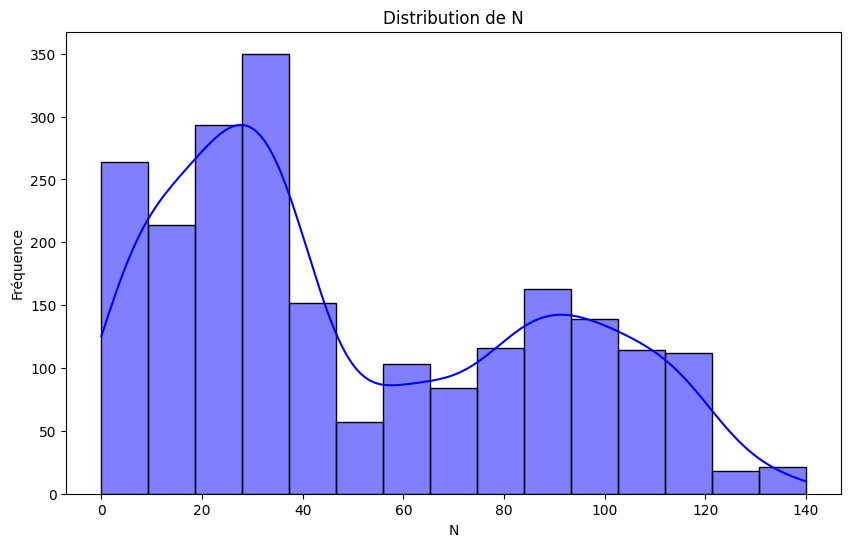

In [ ]:
plot_distribution(df['N'], 'N')

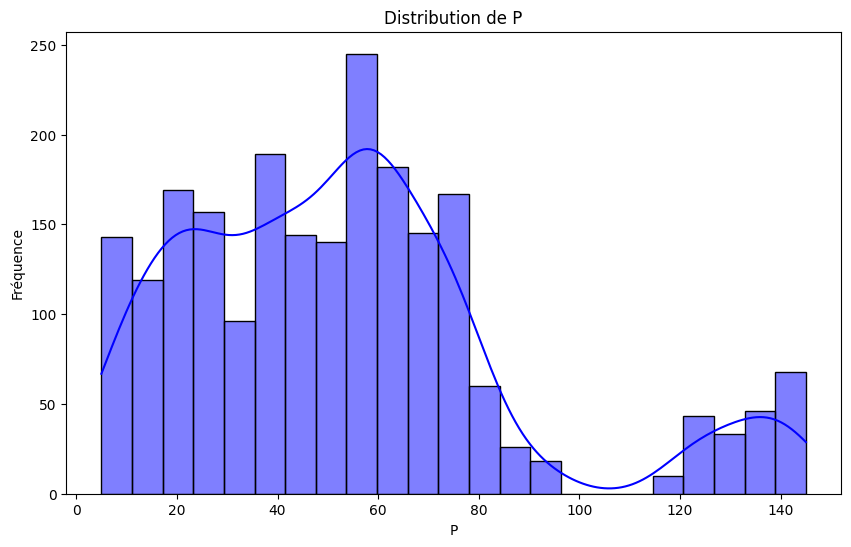

In [ ]:
plot_distribution(df['P'], 'P')

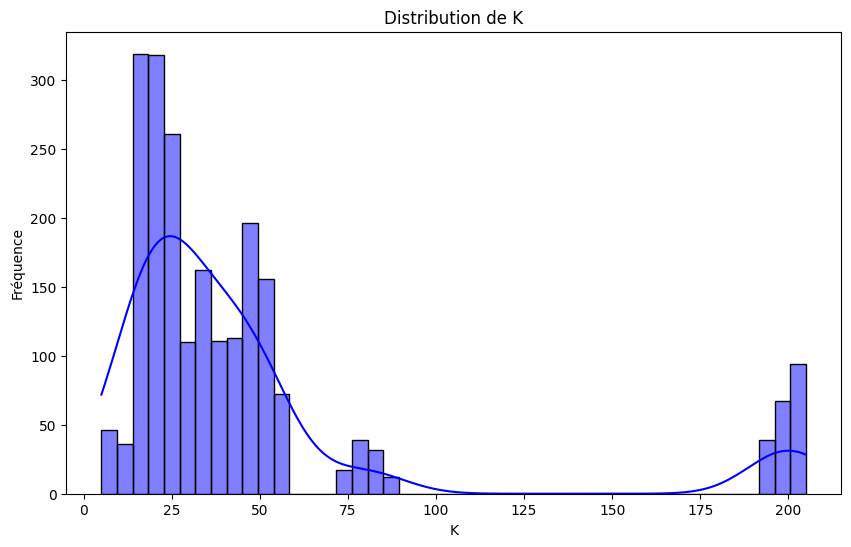

In [ ]:
plot_distribution(df['K'], 'K')

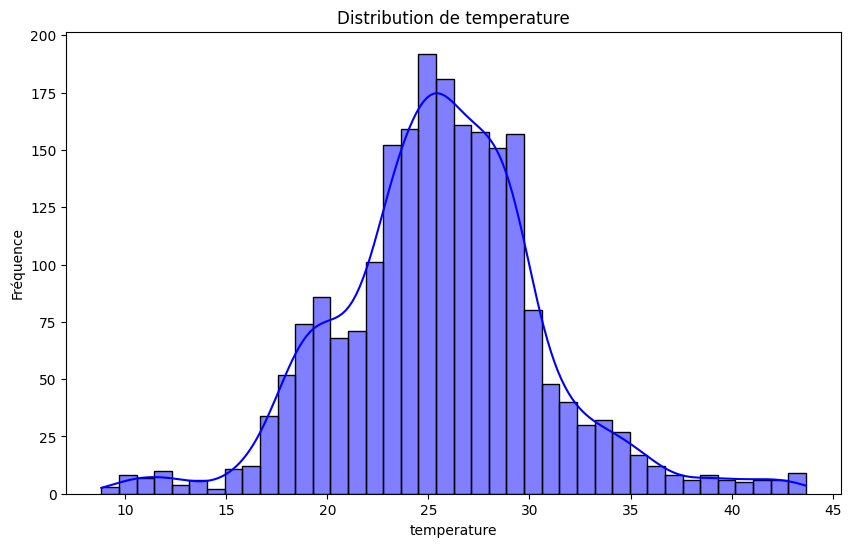

In [ ]:
plot_distribution(df['temperature'], 'temperature')

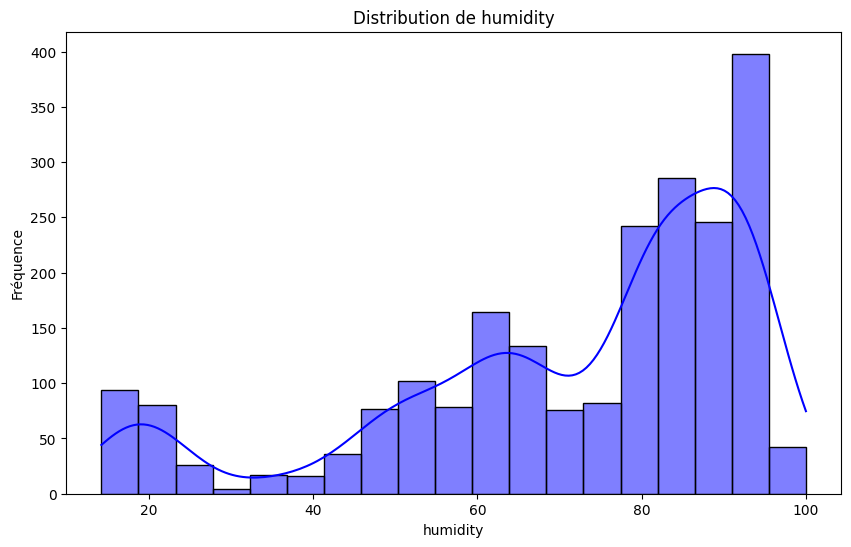

In [ ]:
plot_distribution(df['humidity'], 'humidity')

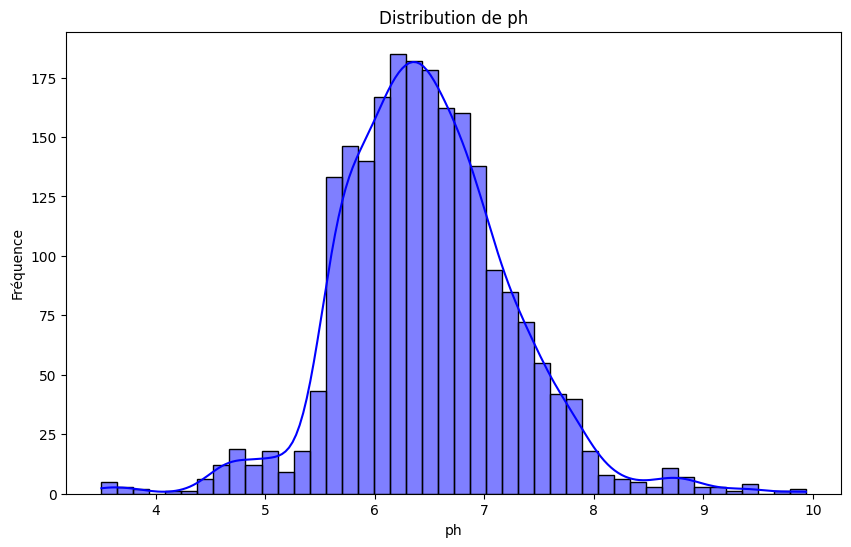

In [ ]:
plot_distribution(df['ph'], 'ph')

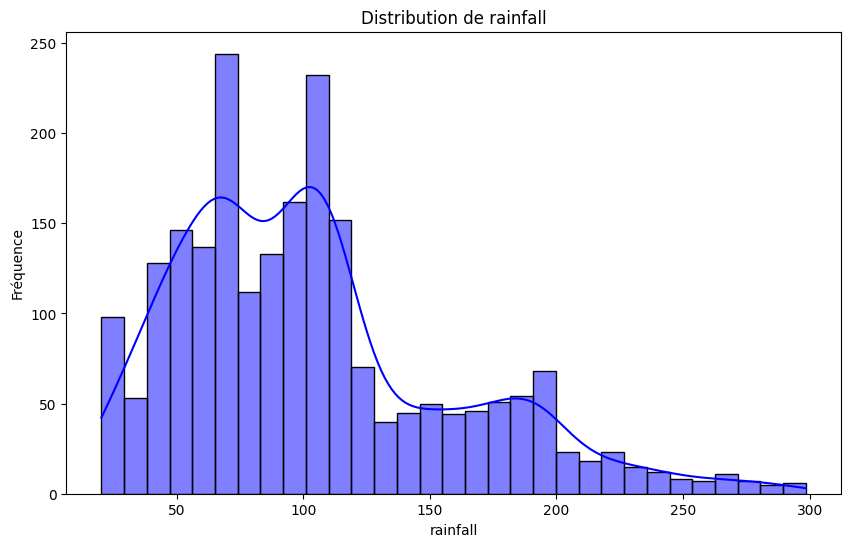

In [ ]:
plot_distribution(df['rainfall'], 'rainfall')

In [ ]:
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


<Axes: xlabel='label', ylabel='count'>

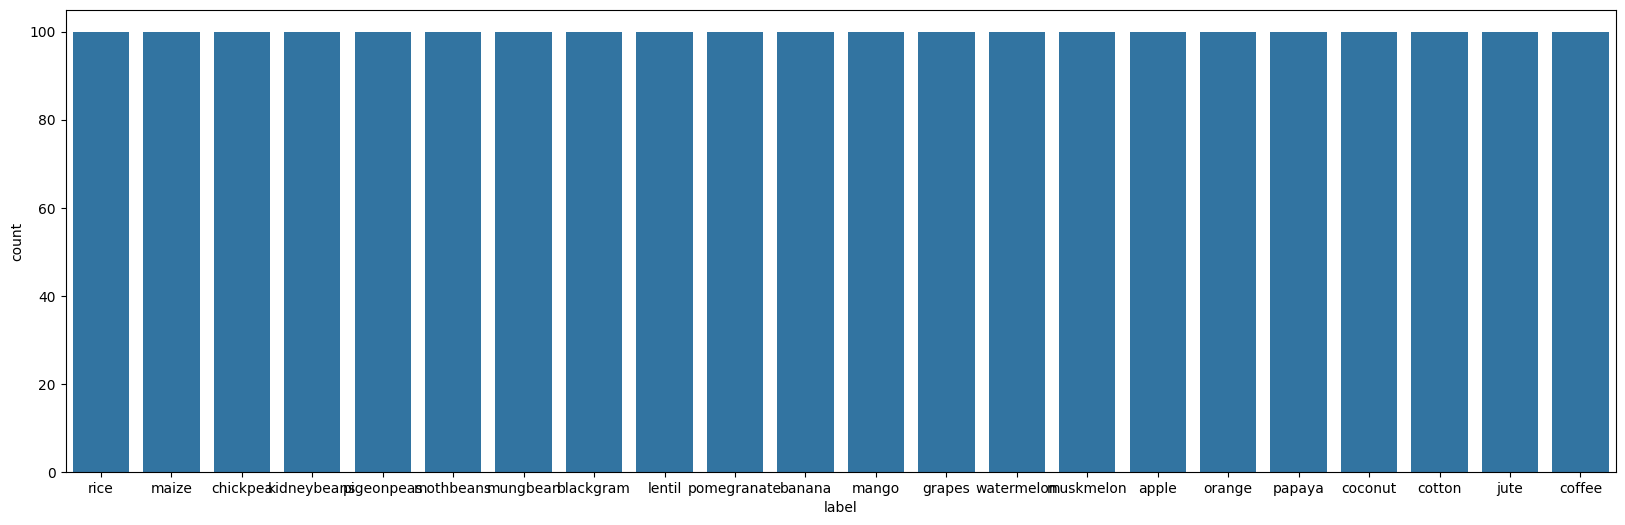

In [ ]:
plt.figure(figsize=(20, 6))
sns.countplot(x='label', data=df)

Les données sont bien équilibrés, pas des valeurs manquantes..etc

# Importer les librairies pour l'entrainement du modèle

In [ ]:
!pip install lightgbm

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
import joblib

In [ ]:
# Séparation des features (X) et de la cible (y)
X = df.drop('label', axis=1)
y = df['label']

In [ ]:
# Encodage des labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)


In [ ]:
# Split des données (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

In [ ]:
# Entraînement du modèle LightGBM

model = LGBMClassifier(random_state=42, verbose=-1)
model.fit(X_train, y_train)

LGBMClassifier(random_state=42, verbose=-1)

In [ ]:
# Évaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nPrécision (Accuracy) : {accuracy * 100:.2f}%\n")


Précision (Accuracy) : 98.86%



In [ ]:
# Affichage des détails
print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Rapport de classification :
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20

In [ ]:
# Matrice de confusion
def plot_matrix_cn(y_test, y_pred):
  conf_matrix = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
  plt.xlabel('Valeurs prédites')
  plt.ylabel('Valeurs réelles')
  plt.title('Matrice de confusion')
  plt.show()

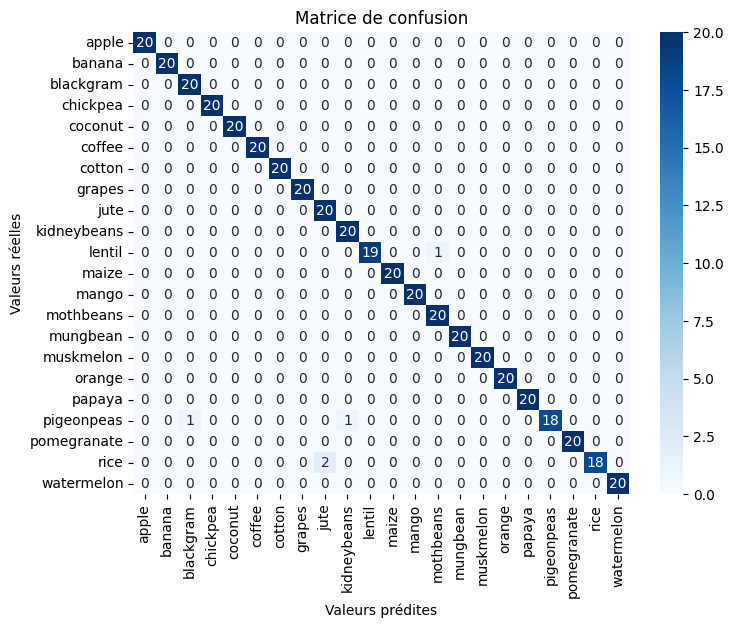

In [ ]:
plot_matrix_cn(y_test,y_pred)

In [ ]:
# random forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Évaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nPrécision Random Forest (Accuracy) : {accuracy * 100:.2f}%\n")


Précision Random Forest (Accuracy) : 99.55%



In [ ]:
print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Rapport de classification :
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20

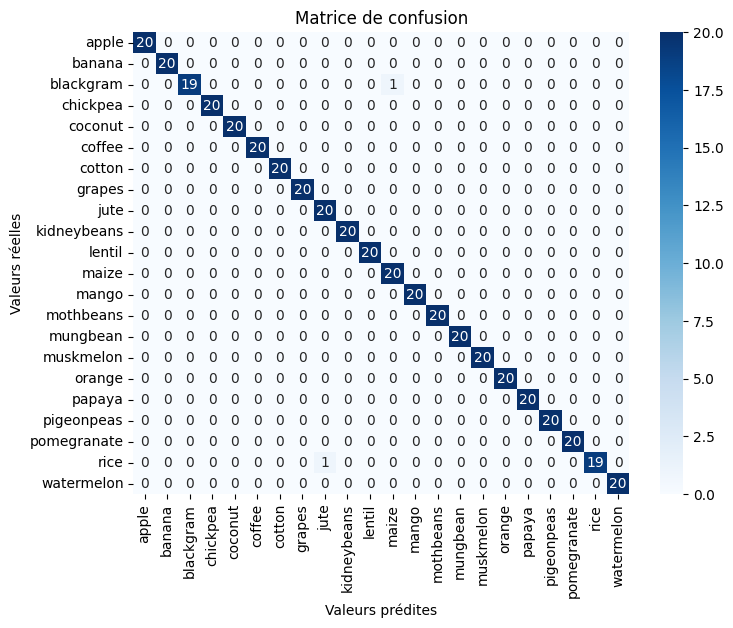

In [ ]:
plot_matrix_cn(y_test,y_pred)

In [ ]:
joblib.dump(model, 'rf_crop_model.pkl')

['rf_crop_model.pkl']

In [ ]:
# enregistrer labelEncoder
joblib.dump(encoder, 'label_encoder.pkl')

['label_encoder.pkl']